# Clinical Relevance Analysis

Formal verification (Marabou) confirmed that the trained network satisfies `safeFar` and `safeNear` —
no input in the verified domain produces an unsafe dose. This notebook asks the separate question:
**are the dose predictions clinically meaningful?**

A network can be formally safe but therapeutically useless if it systematically under- or over-doses
patients, particularly those with unusual pharmacokinetics (fast elimination, extremes of age/weight).

**Model evaluated:** `models/pk_model.keras` (5 features: C, T, WBC, Age, Weight — no D_prev)  
**Verification parameters:** Ka=4.5, Ke=3.5, Vd=10, C_safe=30 mg/L, eps=0.001

### Sections
1. Setup
2. Predictions vs targets
3. Error distribution
4. Residuals by feature
5. Effective Ke analysis — fast-elimination patients
6. Worst-case predictions
7. Safety margin behaviour
8. Interpretation


## 1. Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from drug_verification.simulation import simulate_cohort, generate_patient_covariates, compute_effective_params
from drug_verification.training import prepare_data
from drug_verification.types import SimulationConfig
from drug_verification import constants as C

MODEL_PATH = "models/pk_model.keras"   # verified model
NUM_PATIENTS = 50
TIMESTEPS    = 48
SEED         = 42
ROWS_PER_PATIENT = TIMESTEPS - 1   # 47

tf.random.set_seed(SEED)
np.random.seed(SEED)

model = tf.keras.models.load_model(MODEL_PATH)
print(f"Loaded: {MODEL_PATH}")
model.summary()

Loaded: models/pk_model_exp3.keras


E0000 00:00:1775126444.686910   16923 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/melon501/source/drug-verification/venv_clinical/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,269 (106.52 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,180 (71.02 KB)

In [4]:
cfg = SimulationConfig(num_patients=NUM_PATIENTS, timesteps=TIMESTEPS, seed=SEED)
X, y = simulate_cohort(cfg, seed=SEED)

_, _, _, _, scaler = prepare_data(X, y, seed=SEED)

# Scale and predict
X_scaled = scaler.transform(X)
y_pred = model.predict(X_scaled, verbose=0).flatten()
residuals = y_pred - y

# Patient index for each row (used throughout)
patient_ids = np.repeat(np.arange(NUM_PATIENTS), ROWS_PER_PATIENT)
timestep_ids = np.tile(np.arange(ROWS_PER_PATIENT), NUM_PATIENTS)

print(f"Samples: {X.shape[0]}  ({NUM_PATIENTS} patients x {ROWS_PER_PATIENT} timesteps)")
print(f"MAE:              {np.mean(np.abs(residuals)):.2f} mg")
print(f"Max absolute err: {np.max(np.abs(residuals)):.2f} mg")
print(f"Bias (mean err):  {np.mean(residuals):+.2f} mg  ({'over' if np.mean(residuals) > 0 else 'under'}dosing on average)")

Samples: 2350  (50 patients x 47 timesteps)
MAE:              7.15 mg
Max absolute err: 260.37 mg
Bias (mean err):  +0.56 mg  (overdosing on average)


## 2. Predictions vs targets

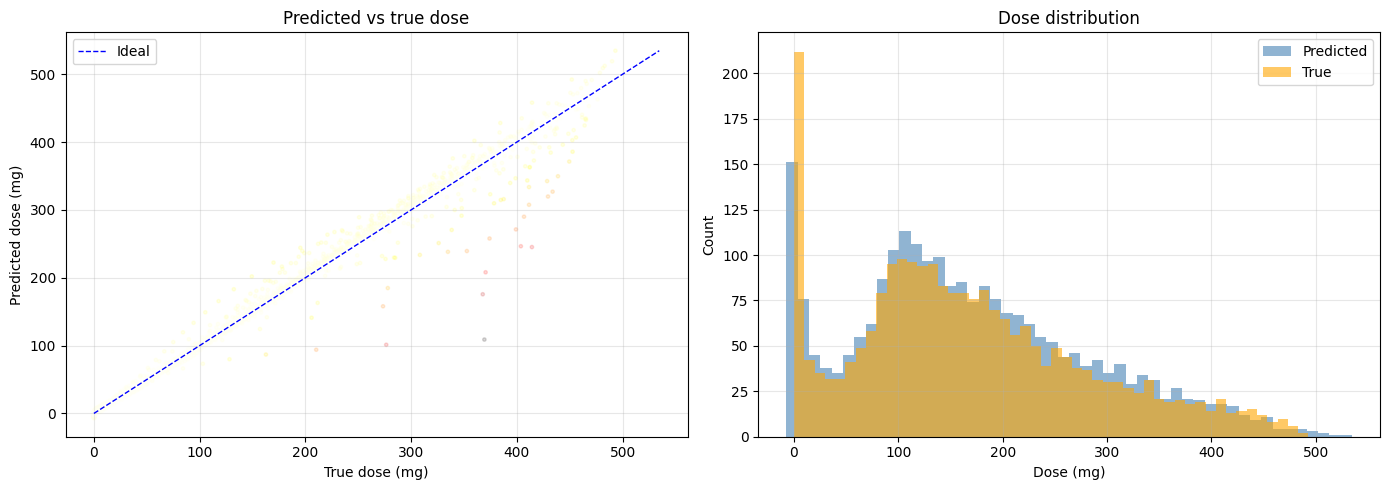

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(y, y_pred, alpha=0.15, s=6, c=np.abs(residuals), cmap='hot_r')
lim = [0, max(y.max(), y_pred.max())]
ax.plot(lim, lim, 'b--', linewidth=1, label='Ideal')
ax.set_xlabel('True dose (mg)')
ax.set_ylabel('Predicted dose (mg)')
ax.set_title('Predicted vs true dose')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(y_pred, bins=50, alpha=0.6, label='Predicted', color='steelblue')
ax.hist(y, bins=50, alpha=0.6, label='True', color='orange')
ax.set_xlabel('Dose (mg)')
ax.set_ylabel('Count')
ax.set_title('Dose distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Error distribution

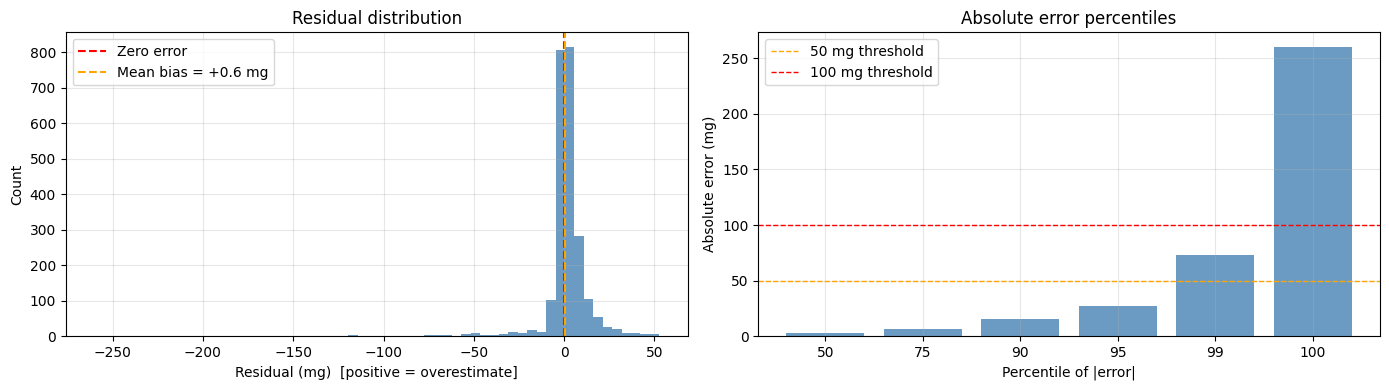

Absolute error percentiles:
   50th: 3.1 mg
   75th: 6.6 mg
   90th: 15.6 mg
   95th: 27.1 mg
   99th: 73.2 mg
  100th: 260.4 mg


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(residuals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
ax.axvline(np.mean(residuals), color='orange', linestyle='--', linewidth=1.5,
           label=f'Mean bias = {np.mean(residuals):+.1f} mg')
ax.set_xlabel('Residual (mg)  [positive = overestimate]')
ax.set_ylabel('Count')
ax.set_title('Residual distribution')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
percentiles = [50, 75, 90, 95, 99, 100]
abs_errs = [np.percentile(np.abs(residuals), p) for p in percentiles]
bars = ax.bar([str(p) for p in percentiles], abs_errs, color='steelblue', alpha=0.8)
ax.axhline(50, color='orange', linestyle='--', linewidth=1, label='50 mg threshold')
ax.axhline(100, color='red', linestyle='--', linewidth=1, label='100 mg threshold')
ax.set_xlabel('Percentile of |error|')
ax.set_ylabel('Absolute error (mg)')
ax.set_title('Absolute error percentiles')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Absolute error percentiles:")
for p, e in zip(percentiles, abs_errs):
    print(f"  {p:3d}th: {e:.1f} mg")

## 4. Residuals by feature

Systematic patterns here indicate that the model has learned a biased response for a particular patient subgroup or physiological state.

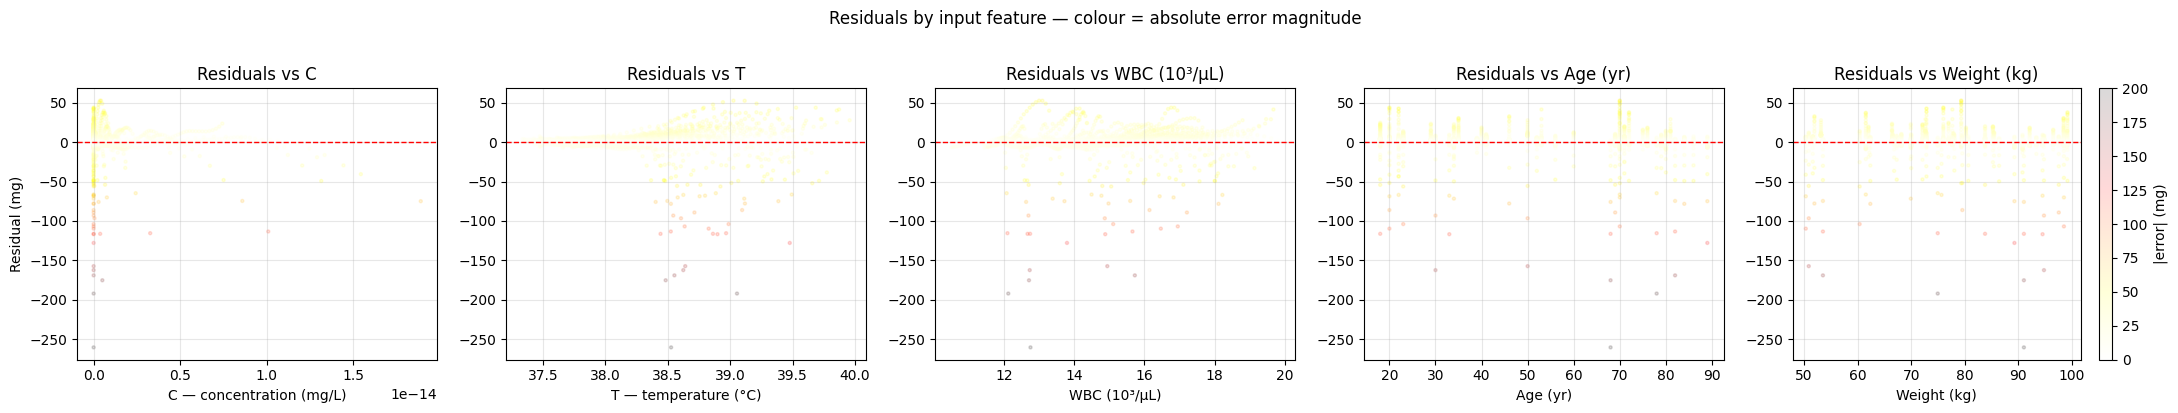

In [7]:
feature_names = ['C — concentration (mg/L)', 'T — temperature (°C)', 'WBC (10³/µL)', 'Age (yr)', 'Weight (kg)']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, (ax, name) in enumerate(zip(axes, feature_names)):
    sc = ax.scatter(X[:, i], residuals, alpha=0.15, s=5,
                    c=np.abs(residuals), cmap='hot_r', vmin=0, vmax=200)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel(name)
    ax.set_ylabel('Residual (mg)' if i == 0 else '')
    ax.set_title(f'Residuals vs {name.split("—")[0].strip()}')
    ax.grid(True, alpha=0.3)

plt.colorbar(sc, ax=axes[-1], label='|error| (mg)')
plt.suptitle('Residuals by input feature — colour = absolute error magnitude', y=1.02)
plt.tight_layout()
plt.show()

## 5. Effective Ke analysis

Each patient's elimination rate is adjusted by age:

    ke_eff = Ke_baseline × (1 − 0.004 × (age − 50))

Older patients have lower effective Ke (slower elimination), younger patients higher Ke (faster elimination).
Fast-elimination patients reach lower trough concentrations, which is what caused the NaN issue during training.
The question here is whether the model is less accurate for those patients.


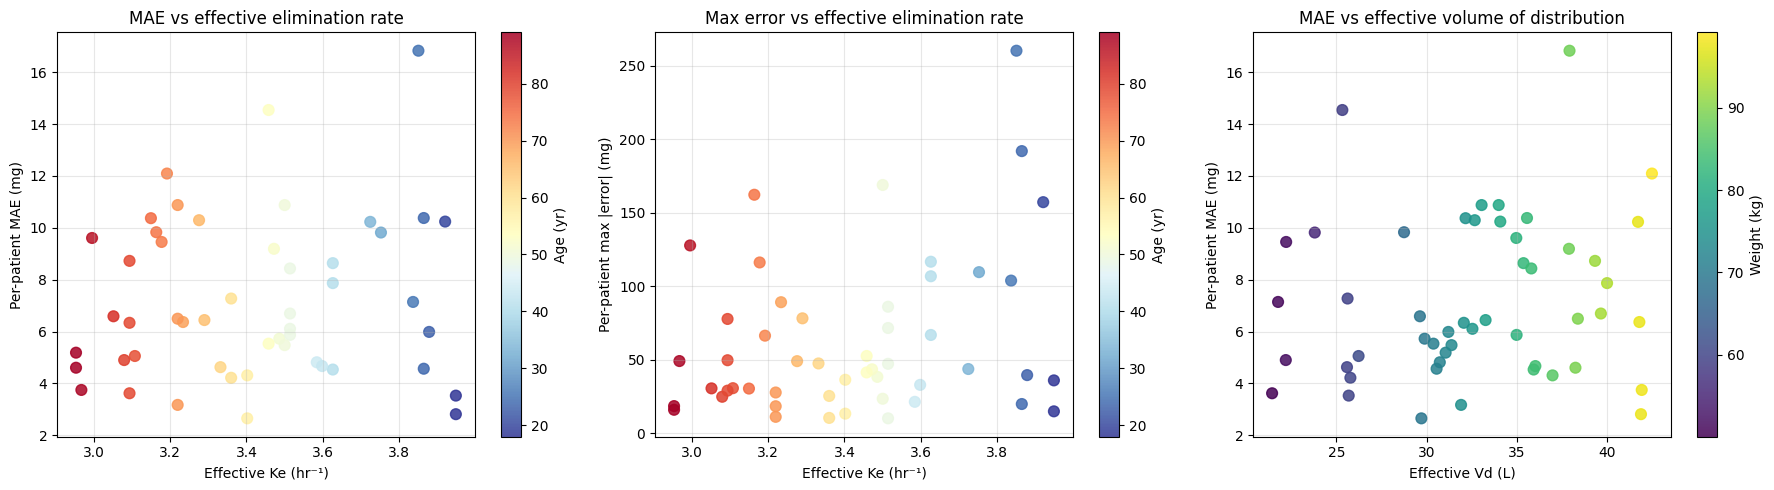

Correlation: ke_eff vs per-patient MAE:  r = 0.109
Correlation: ke_eff vs per-patient max:  r = 0.286
Correlation: age    vs per-patient MAE:  r = -0.109


In [8]:
# Rerun simulation to collect per-patient covariates and effective params
rng = np.random.RandomState(SEED)
patient_ages    = []
patient_weights = []
patient_ke_eff  = []
patient_ka_eff  = []
patient_vd_eff  = []

for _ in range(NUM_PATIENTS):
    pat = generate_patient_covariates(rng)
    eff = compute_effective_params(pat, cfg, rng)
    patient_ages.append(pat.age)
    patient_weights.append(pat.weight)
    patient_ke_eff.append(eff.ke_eff)
    patient_ka_eff.append(eff.ka_eff)
    patient_vd_eff.append(eff.Vd_eff)

patient_ages    = np.array(patient_ages)
patient_ke_eff  = np.array(patient_ke_eff)
patient_ka_eff  = np.array(patient_ka_eff)
patient_vd_eff  = np.array(patient_vd_eff)

# Per-patient MAE and max error
per_patient_mae = np.array([
    np.mean(np.abs(residuals[patient_ids == i])) for i in range(NUM_PATIENTS)
])
per_patient_max = np.array([
    np.max(np.abs(residuals[patient_ids == i])) for i in range(NUM_PATIENTS)
])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
sc = ax.scatter(patient_ke_eff, per_patient_mae, c=patient_ages, cmap='RdYlBu_r', s=60, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Age (yr)')
ax.set_xlabel('Effective Ke (hr⁻¹)')
ax.set_ylabel('Per-patient MAE (mg)')
ax.set_title('MAE vs effective elimination rate')
ax.grid(True, alpha=0.3)

ax = axes[1]
sc = ax.scatter(patient_ke_eff, per_patient_max, c=patient_ages, cmap='RdYlBu_r', s=60, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Age (yr)')
ax.set_xlabel('Effective Ke (hr⁻¹)')
ax.set_ylabel('Per-patient max |error| (mg)')
ax.set_title('Max error vs effective elimination rate')
ax.grid(True, alpha=0.3)

ax = axes[2]
sc = ax.scatter(patient_vd_eff, per_patient_mae, c=patient_weights, cmap='viridis', s=60, alpha=0.85)
plt.colorbar(sc, ax=ax, label='Weight (kg)')
ax.set_xlabel('Effective Vd (L)')
ax.set_ylabel('Per-patient MAE (mg)')
ax.set_title('MAE vs effective volume of distribution')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Correlation: ke_eff vs per-patient MAE:  r = {np.corrcoef(patient_ke_eff, per_patient_mae)[0,1]:.3f}")
print(f"Correlation: ke_eff vs per-patient max:  r = {np.corrcoef(patient_ke_eff, per_patient_max)[0,1]:.3f}")
print(f"Correlation: age    vs per-patient MAE:  r = {np.corrcoef(patient_ages, per_patient_mae)[0,1]:.3f}")

## 6. Worst-case predictions

Identify the timesteps with the largest absolute errors and profile those patients.

In [9]:
N_WORST = 10
worst_idx = np.argsort(np.abs(residuals))[-N_WORST:][::-1]

print(f"{'Rank':<5} {'|Error|':>8} {'Residual':>10} {'True':>8} {'Pred':>8} "
      f"{'Conc':>6} {'Temp':>6} {'WBC':>6} {'Age':>5} {'Wt':>5} "
      f"{'ke_eff':>7} {'Timestep':>9} {'Patient':>8}")
print("-" * 105)

for rank, idx in enumerate(worst_idx):
    pid = patient_ids[idx]
    ts  = timestep_ids[idx]
    print(f"{rank+1:<5} {abs(residuals[idx]):>8.1f} {residuals[idx]:>+10.1f} "
          f"{y[idx]:>8.1f} {y_pred[idx]:>8.1f} "
          f"{X[idx,0]:>6.1f} {X[idx,1]:>6.2f} {X[idx,2]:>6.1f} "
          f"{X[idx,3]:>5.0f} {X[idx,4]:>5.0f} "
          f"{patient_ke_eff[pid]:>7.3f} {ts:>9} {pid:>8}")

print()
worst_patient_ids = np.unique(patient_ids[worst_idx])
print(f"Worst-case patients (IDs): {worst_patient_ids}")
print(f"Their ages:    {patient_ages[worst_patient_ids]}")
print(f"Their ke_eff:  {np.round(patient_ke_eff[worst_patient_ids], 3)}")

Rank   |Error|   Residual     True     Pred   Conc   Temp    WBC   Age    Wt  ke_eff  Timestep  Patient
---------------------------------------------------------------------------------------------------------
1        260.4     -260.4    369.2    108.9    0.0  38.53   12.8    68    91   3.850         0       33
2        192.1     -192.1    367.7    175.6    0.0  39.06   12.1    78    75   3.864         0       21
3        175.2     -175.2    276.4    101.2    0.0  38.48   12.7    68    91   3.850         1       33
4        169.0     -169.0    414.2    245.2    0.0  38.55   15.7    82    54   3.500         0       25
5        162.4     -162.4    370.4    208.0    0.0  38.62   12.7    30    95   3.164         0       37
6        157.3     -157.3    403.7    246.4    0.0  38.64   14.9    50    51   3.920         0       19
7        127.9     -127.9    399.1    271.2    0.0  39.48   13.8    89    89   2.996         0       18
8        116.8     -116.8    406.7    290.0    0.0  38.90   14

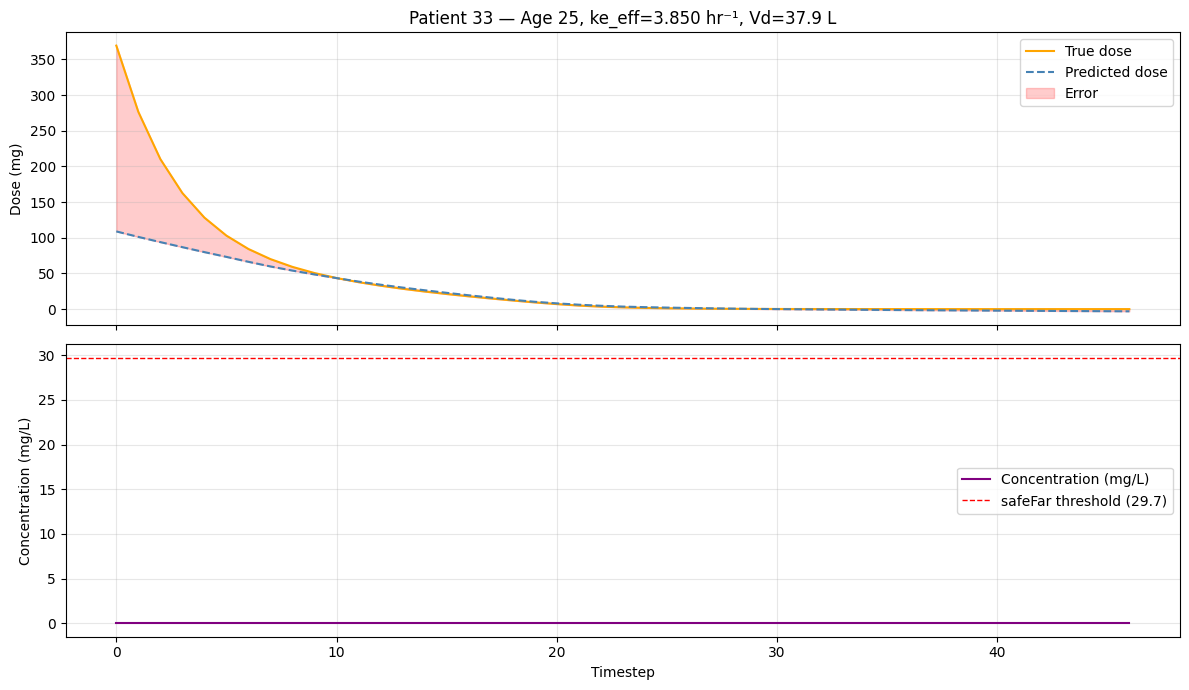

In [10]:
# Plot dose trajectory for the single worst patient
worst_patient = patient_ids[worst_idx[0]]

mask = patient_ids == worst_patient
ts   = timestep_ids[mask]
sort = np.argsort(ts)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
ax.plot(ts[sort], y[mask][sort], label='True dose', color='orange')
ax.plot(ts[sort], y_pred[mask][sort], label='Predicted dose', color='steelblue', linestyle='--')
ax.fill_between(ts[sort],
                y[mask][sort], y_pred[mask][sort],
                alpha=0.2, color='red', label='Error')
ax.set_ylabel('Dose (mg)')
ax.set_title(f'Patient {worst_patient} — Age {patient_ages[worst_patient]}, '
             f'ke_eff={patient_ke_eff[worst_patient]:.3f} hr⁻¹, Vd={patient_vd_eff[worst_patient]:.1f} L')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ts[sort], X[mask][sort, 0], color='purple', label='Concentration (mg/L)')
ax.axhline(C.C_MAX * 0.99, color='red', linestyle='--', linewidth=1, label='safeFar threshold (29.7)')
ax.set_xlabel('Timestep')
ax.set_ylabel('Concentration (mg/L)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Safety margin behaviour

The verified properties only cover:
- `safeFar`: conc ∈ [0, 29.7] — model must not push concentration over C_safe
- `safeNear`: conc ∈ [29.7, 30] — model must prescribe near-zero dose

This section checks whether the model is clinically conservative near the threshold —
i.e. does it gradually reduce doses as concentration approaches C_safe, or does it drop abruptly?


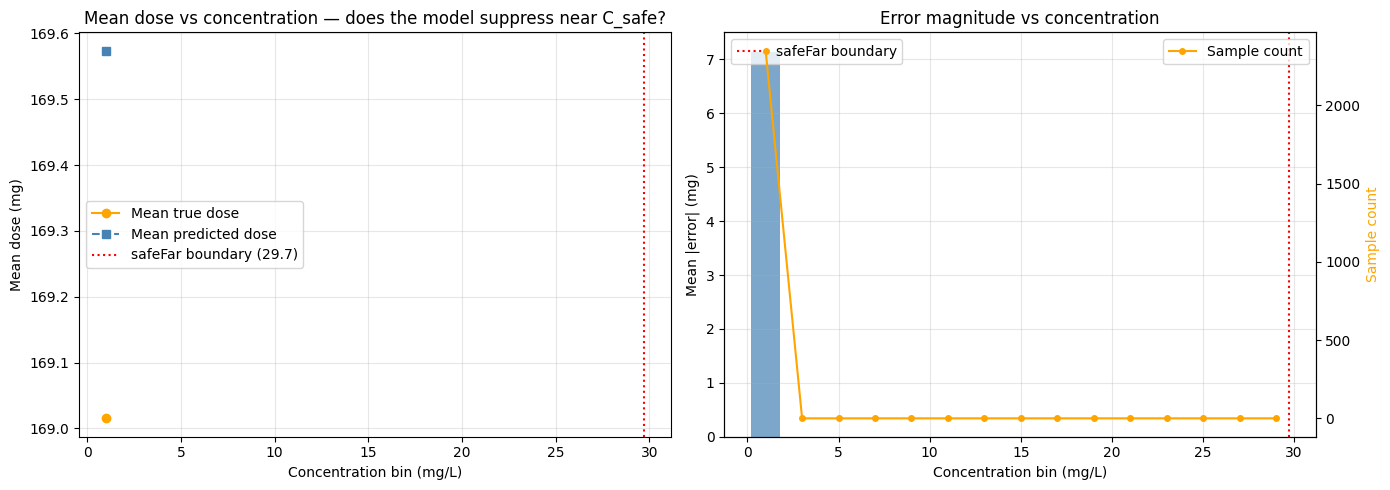

In [11]:
conc = X[:, 0]
bins = np.linspace(0, C.C_MAX, 16)
bin_idx = np.digitize(conc, bins) - 1

bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_mae  = [np.mean(np.abs(residuals[bin_idx == i])) if np.any(bin_idx == i) else np.nan
            for i in range(len(bins) - 1)]
bin_pred = [np.mean(y_pred[bin_idx == i]) if np.any(bin_idx == i) else np.nan
            for i in range(len(bins) - 1)]
bin_true = [np.mean(y[bin_idx == i]) if np.any(bin_idx == i) else np.nan
            for i in range(len(bins) - 1)]
bin_count = [np.sum(bin_idx == i) for i in range(len(bins) - 1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(bin_centers, bin_true, 'o-', color='orange', label='Mean true dose')
ax.plot(bin_centers, bin_pred, 's--', color='steelblue', label='Mean predicted dose')
ax.axvline(C.C_MAX * 0.99, color='red', linestyle=':', linewidth=1.5, label='safeFar boundary (29.7)')
ax.set_xlabel('Concentration bin (mg/L)')
ax.set_ylabel('Mean dose (mg)')
ax.set_title('Mean dose vs concentration — does the model suppress near C_safe?')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(bin_centers, bin_mae, width=(bins[1]-bins[0])*0.8, color='steelblue', alpha=0.7)
ax.axvline(C.C_MAX * 0.99, color='red', linestyle=':', linewidth=1.5, label='safeFar boundary')
ax2 = ax.twinx()
ax2.plot(bin_centers, bin_count, 'o-', color='orange', markersize=4, label='Sample count')
ax2.set_ylabel('Sample count', color='orange')
ax.set_xlabel('Concentration bin (mg/L)')
ax.set_ylabel('Mean |error| (mg)')
ax.set_title('Error magnitude vs concentration')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Interpretation

In [12]:
# Summary statistics
mae = np.mean(np.abs(residuals))
max_err = np.max(np.abs(residuals))
p95 = np.percentile(np.abs(residuals), 95)
p99 = np.percentile(np.abs(residuals), 99)
bias = np.mean(residuals)
pct_within_50  = 100 * np.mean(np.abs(residuals) < 50)
pct_within_100 = 100 * np.mean(np.abs(residuals) < 100)

worst_ke_corr = np.corrcoef(patient_ke_eff, per_patient_max)[0, 1]

print("=" * 55)
print("  Clinical Relevance Summary")
print("=" * 55)
print(f"  MAE                   {mae:>8.1f} mg")
print(f"  95th percentile error {p95:>8.1f} mg")
print(f"  99th percentile error {p99:>8.1f} mg")
print(f"  Max absolute error    {max_err:>8.1f} mg")
print(f"  Mean bias             {bias:>+8.1f} mg  ({'over' if bias > 0 else 'under'}dosing)")
print(f"  Within 50 mg          {pct_within_50:>7.1f}%")
print(f"  Within 100 mg         {pct_within_100:>7.1f}%")
print()
print(f"  ke_eff vs max error (r)  {worst_ke_corr:>+.3f}")
print("=" * 55)
print()
print("Formal safety: VERIFIED (safeFar, safeNear, nonNeg)")
print()
if abs(worst_ke_corr) > 0.3:
    direction = "positively" if worst_ke_corr > 0 else "negatively"
    print(f"Elimination rate is {direction} correlated with worst-case error")
    print("(fast-elimination patients may be harder to dose accurately).")
else:
    print("Worst-case error does not strongly correlate with elimination rate.")
print()
print("Open question: are 260 mg outliers at clinically dangerous doses,")
print("or low doses where the absolute error is large but the clinical")
print("consequence is small (e.g. 10 mg predicted vs 270 mg true when")
print("the patient is near-normal)?")

  Clinical Relevance Summary
  MAE                        7.1 mg
  95th percentile error     27.1 mg
  99th percentile error     73.2 mg
  Max absolute error       260.4 mg
  Mean bias                 +0.6 mg  (overdosing)
  Within 50 mg             98.3%
  Within 100 mg            99.4%

  ke_eff vs max error (r)  +0.286

Formal safety: VERIFIED (safeFar, safeNear, nonNeg)

Worst-case error does not strongly correlate with elimination rate.

Open question: are 260 mg outliers at clinically dangerous doses,
or low doses where the absolute error is large but the clinical
consequence is small (e.g. 10 mg predicted vs 270 mg true when
the patient is near-normal)?
